In [45]:
import torch
from torch.utils import data
from models import ClsModel
from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

In [46]:
plt.style.use('default')

In [47]:
if torch.cuda.is_available():
    device = "cuda"
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"

In [48]:
cls_model_path = "weights/cls_model_0.95.pt"

In [49]:
cls_model = ClsModel()
cls_model.load_state_dict(torch.load(cls_model_path, weights_only=True))
cls_model.to(device)

cls_model_cropped = cls_model.fc[:-2]

print("Cropped model:\n", cls_model_cropped)

Cropped model:
 Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=2352, out_features=512, bias=True)
  (2): Tanh()
  (3): Linear(in_features=512, out_features=64, bias=True)
  (4): Tanh()
  (5): Linear(in_features=64, out_features=8, bias=True)
)


In [50]:
pca = PCA(n_components=2)

In [51]:
clean_val_dataset = torch.load("./data/clean_val_dataset.pt", weights_only=False)
fully_colored_val_dataset = torch.load("./data/fully_colored_val_dataset.pt", weights_only=False)
colors_flipped_val_dataset = torch.load("./data/colors_flipped_val_dataset.pt", weights_only=False)

clean_val_dataloader = data.DataLoader(clean_val_dataset, batch_size=32, shuffle=False)
fully_colored_val_dataloader = data.DataLoader(fully_colored_val_dataset, batch_size=32, shuffle=False)
colors_flipped_val_dataloader = data.DataLoader(colors_flipped_val_dataset, batch_size=32, shuffle=False)

In [52]:
clean_hidden_list = []
clean_targets_list = []

fully_colored_hidden_list = []
fully_colored_targets_list = []
colors_flipped_hidden_list = []
colors_flipped_targets_list = []

for x, y in clean_val_dataloader:
    x = x.to(device)
    hidden = cls_model_cropped(x)
    clean_hidden_list.extend(hidden.cpu().detach().tolist())
    clean_targets_list.extend(y.cpu().detach().tolist())

for x, y in fully_colored_val_dataloader:
    x = x.to(device)
    hidden = cls_model_cropped(x)
    fully_colored_hidden_list.extend(hidden.cpu().detach().tolist())
    fully_colored_targets_list.extend(y.cpu().detach().tolist())

for x, y in colors_flipped_val_dataloader:
    x = x.to(device)
    hidden = cls_model_cropped(x)
    colors_flipped_hidden_list.extend(hidden.cpu().detach().tolist())
    colors_flipped_targets_list.extend(y.cpu().detach().tolist())

clean_hidden_array = np.array(clean_hidden_list)
fully_colored_hidden_array = np.array(fully_colored_hidden_list)
colors_flipped_hidden_array = np.array(colors_flipped_hidden_list)

clean_targets_array = np.array(clean_targets_list)
fully_colored_targets_array = np.array(fully_colored_targets_list) + 10 # Add 10 to the fully colored targets to differentiate them from the clean targets
colors_flipped_targets_array = np.array(colors_flipped_targets_list) + 20 # Add 20 to the colors flipped targets to differentiate them from the clean and fully colored targets

merged_hidden_array = np.concatenate((clean_hidden_array, fully_colored_hidden_array, colors_flipped_hidden_array), axis=0)
merged_targets_array = np.concatenate((clean_targets_array, fully_colored_targets_array, colors_flipped_targets_array), axis=0)

In [53]:
hidden_transformed = pca.fit_transform(merged_hidden_array)

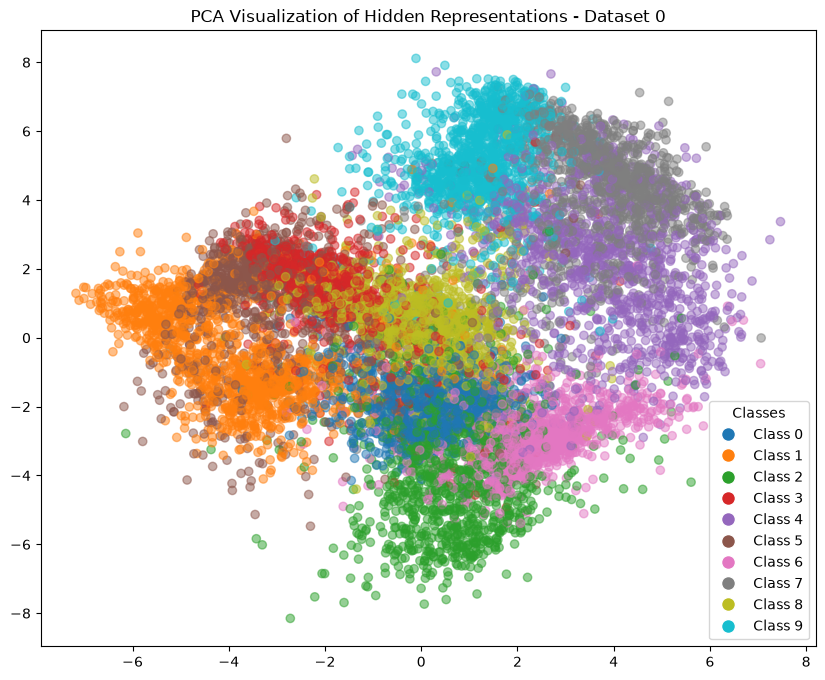

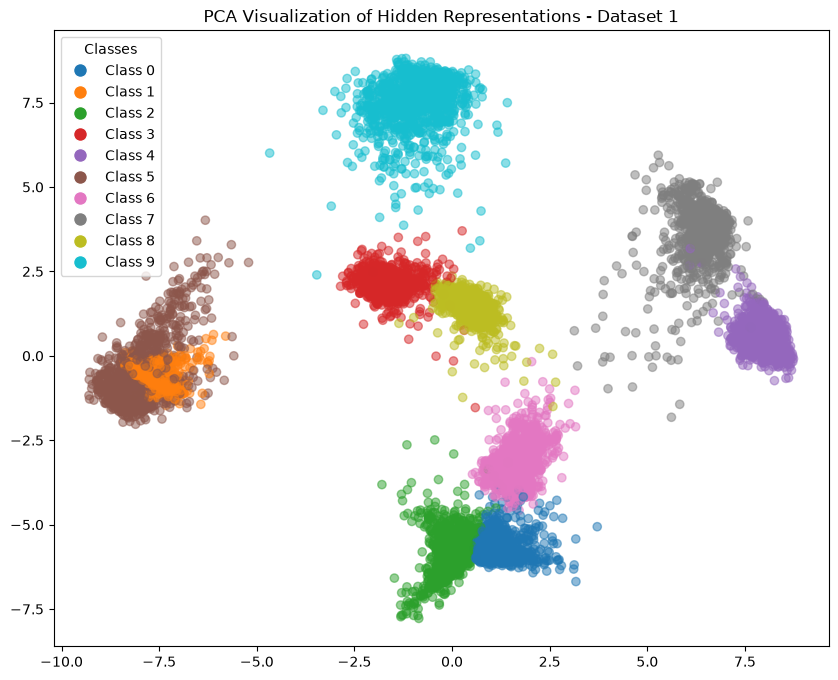

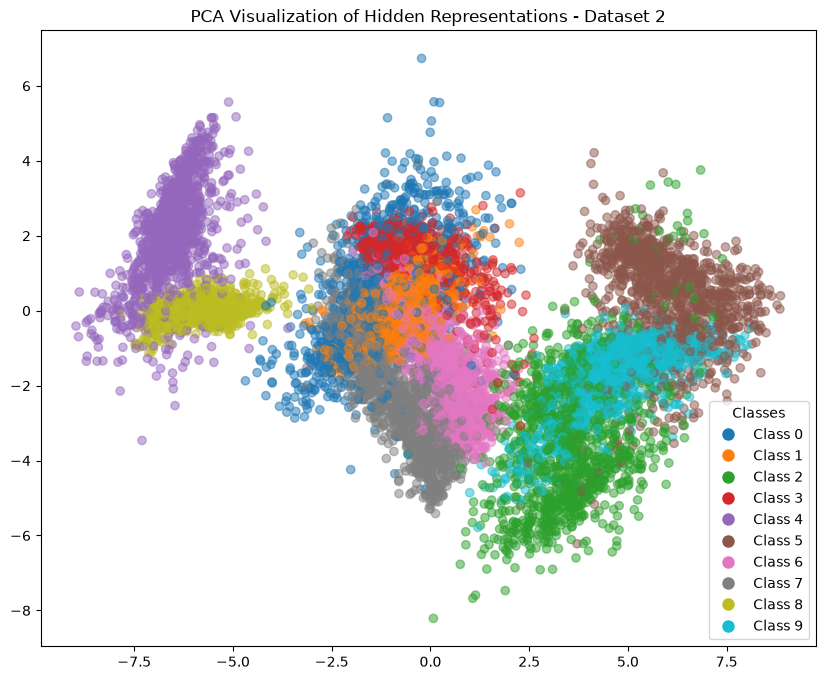

In [54]:
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf']

cmap = ListedColormap(colors)


for i in range(3):
    plt.figure(figsize=(10, 8))
    plt.title(f'PCA Visualization of Hidden Representations - Dataset {i}')
    
    if i == 0:
        hidden_transformed_subset = hidden_transformed[:len(clean_hidden_array)]
        labels = clean_targets_array
    elif i == 1:
        hidden_transformed_subset = hidden_transformed[len(clean_hidden_array):len(clean_hidden_array) + len(fully_colored_hidden_array)]
        labels = fully_colored_targets_array
    else:
        hidden_transformed_subset = hidden_transformed[len(clean_hidden_array) + len(fully_colored_hidden_array):]
        labels = colors_flipped_targets_array

    # Convert labels to a NumPy array if they are PyTorch tensors
    labels = np.asarray(labels)

    plt.scatter(hidden_transformed_subset[:, 0], hidden_transformed_subset[:, 1],     c=labels,
        cmap=cmap,
        alpha=0.5
    )

    plt.legend(handles=[plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=color, markersize=10, label=f'Class {i}') for i, color in enumerate(colors)], title='Classes')
    plt.show()